In [81]:
import os
from cryoquake import stream_handling as sh
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from obspy.core.inventory import inventory
from obspy.core import Stream, Trace, read, UTCDateTime
import pandas as pd
from scipy.signal import correlate
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [82]:
t1 = sh.UTCDateTime(2019,1,5)
t2 = sh.UTCDateTime(2019,1,6)


chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "waveforms"
stack_path = root / "stacked_waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / "all_stations"



inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

network_cat = do.EventCatalogue(t1,t2,c_path)


c_path = root / "catalogues" / "all_stations"


buffer = 5
#want to now do this with daychunk loops so not attaching and filtering each event individually?
#so get daystream, filter, and chop out the filtered sections (as done in the notebook)
all_traces = []

for daychunk in chunk:
    print('Attaching and processing waveforms for ' + str(daychunk.starttime.date) + '...')
    #want to attach and filter the waveforms for this day

    daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
    daychunk.decimate(5)
    daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

    day_cat = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path)

    print('Processing ' + str(day_cat.N) + ' events for ' + str(daychunk.starttime.date) + '...')

    for event in day_cat:
        event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
        all_traces.append(np.stack([tr.data for tr in event_stream],axis=1)) #stacked array of [time,stations] for each event

Attaching and processing waveforms for 2019-01-05...
Processing 315 events for 2019-01-05...


In [83]:
X = np.stack(all_traces,axis=0) #stacked array of [events,time,stations]
X = X - X.mean(axis=1, keepdims=True)
X /= np.linalg.norm(X, axis=1, keepdims=True)

In [84]:
max_lag = 100
all_sim = []

for i in range(X.shape[-1]):
    Y = X[:,:,i]

    similarity = np.full((len(Y), len(Y)), -np.inf)

    for lag in range(-max_lag, max_lag + 1):

        if lag > 0:
            C = Y[:, :-lag] @ Y[:, lag:].T

        elif lag < 0:
            C = Y[:, -lag:] @ Y[:, :lag].T

        else:
            C = Y @ Y.T

        similarity = np.maximum(similarity, C)
    
    all_sim.append(similarity)

all_sim = np.stack(all_sim, axis=0)
cc_mat = np.max(all_sim, axis=0)

(array([13320., 50542., 23188.,  5656.,  2632.,  2046.,  1042.,   276.,
          168.,   355.]),
 array([0.09065275, 0.18158748, 0.2725222 , 0.36345693, 0.45439165,
        0.54532638, 0.6362611 , 0.72719583, 0.81813055, 0.90906528,
        1.        ]),
 <BarContainer object of 10 artists>)

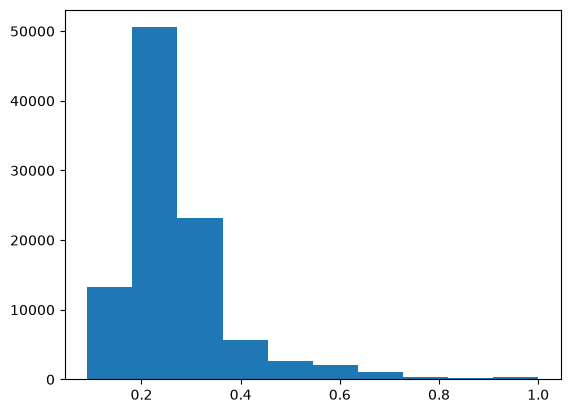

In [85]:
plt.hist(cc_mat.flatten(), bins=10)

In [86]:
cc_mat[cc_mat > 1] = 1.0

dissimilarity = 1-cc_mat
dissimilarity = distance.squareform(dissimilarity) #flattened version - same values as dissimilary so 1 - cc_mat

In [119]:
from scipy.cluster import hierarchy
from scipy.spatial import distance

print('Hierarchial clustering...')
threshold = 0.3 #make this 0.2 to match the correlation detector

linkage = hierarchy.linkage(dissimilarity, method="average",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

Hierarchial clustering...


In [120]:
print('Template matching...')
#clusters = np.load(os.path.join(c_path,'clusters_N.npz'))['clusters']
#cc_mat = np.load(os.path.join(c_path,'cc_matrix_N.npz'))['cc_mat']


unique, counts = np.unique(clusters,return_counts=True)
clust_ind = unique[counts > 3]

templates = {}

for i, clust_N in enumerate(clust_ind):

    cc_ind = np.where(clusters==clust_N)[0]
    temp = cc_mat[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = day_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_N)] = central_id

Template matching...


In [121]:
chunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
chunk.decimate(5)
#chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
chunk.filter('bandpass',freqmin=1,freqmax=30)

In [122]:
templates

{'60': '20190105T031618Z',
 '71': '20190105T114418Z',
 '76': '20190105T105445Z',
 '138': '20190105T214642Z',
 '143': '20190105T171203Z',
 '153': '20190105T035633Z',
 '206': '20190105T231126Z'}

In [129]:
event_row = day_cat.events.loc['20190105T105445Z']
event_start = UTCDateTime(event_row['ref_time'])
event_stream = chunk.stream.slice(event_start-10,event_start+25)

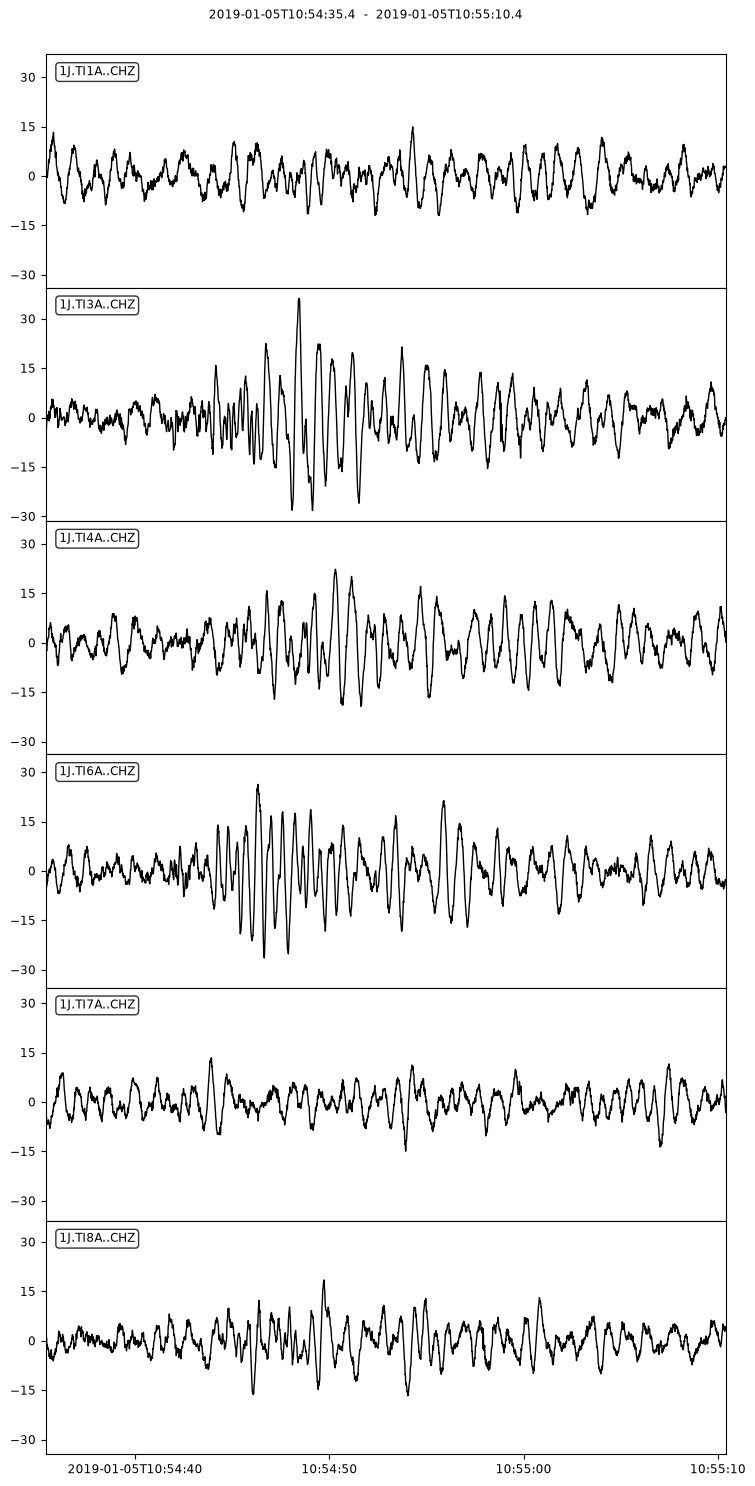

In [130]:
event_stream.plot();